##### COVID Hand Wash AI Assignment-2

In [ ]:
#!pip install numpy

#!pip install tensorflow

#!pip install matplotlib

#!pip install keras

#!pip install scikit-learn

#!pip install opencv-python

## 1. Import required Libraries

In [1]:

import os, glob, shutil, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset / Model constants
IMG_SIZE = (150, 150, 3)  
IMG_SHAPE_HW = (IMG_SIZE[0], IMG_SIZE[1])
NUM_CLASSES = 8
BATCH_SIZE = 32

# Class names
CLASS_NAMES = [f"Stage {i}" for i in range(1, NUM_CLASSES + 1)]


*In this section I import all libraries needed for data handling (NumPy/Pandas), modelling (TensorFlow/Keras), and evaluation (scikit-learn + plotting). I also set a fixed random seed (SEED = 42) to make the results reproducible — meaning my train/validation/test split and training behaviour can be repeated consistently. Finally, I define key constants such as the input image size (150×150×3) and the number of classes (8 stages). Keeping these values central avoids mismatches later (e.g., wrong input shape or incorrect class indexing) and ensures every stage of the pipeline uses the same configuration.*

## 2. Loading the Data

In [2]:
source_folder = "C:/Users/Administrator/Desktop/faiz/CHS2406_Coursework2_Data_Repository"
destination_folder = "C:/Users/Administrator/Desktop/faiz/working_dataset"
label_file_path = os.path.join(destination_folder, "labels.txt")

os.makedirs(destination_folder, exist_ok=True)

VALID_EXTS = (".png", ".jpg", ".jpeg")

def is_image_file(fp: str) -> bool:
    return fp.lower().endswith(VALID_EXTS)

written = 0

with open(label_file_path, "w") as label_file:
    for stage_index in range(1, NUM_CLASSES + 1):
        stage_path = os.path.join(source_folder, f"Stage{stage_index}", "*")
        file_list = glob.glob(stage_path)

        print(f"Processing Stage {stage_index}: {len(file_list)} files found")

        for file_path in file_list:
            if not is_image_file(file_path):
                continue

            filename = os.path.basename(file_path)
            new_filename = f"stage{stage_index}_{filename}"
            dest_path = os.path.join(destination_folder, new_filename)

            try:
                img = Image.open(file_path).convert("RGB")
                img_resized = img.resize((IMG_SIZE[0], IMG_SIZE[1]), Image.Resampling.LANCZOS)
                img_resized.save(dest_path, quality=95)

                # label is 0-based
                label_file.write(f"{new_filename}: {stage_index - 1}\n")
                written += 1
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

print("All images copied and resized to:", destination_folder)


# Correct total count
total_images = len([f for f in os.listdir(destination_folder) if f.lower().endswith(VALID_EXTS)])
print(f"Total labels written: {written}")



Processing Stage 1: 1090 files found
Processing Stage 2: 1089 files found
Processing Stage 3: 1087 files found
Processing Stage 4: 1088 files found
Processing Stage 5: 1082 files found
Processing Stage 6: 1086 files found
Processing Stage 7: 1086 files found
Processing Stage 8: 1099 files found
All images copied and resized to: C:/Users/Administrator/Desktop/faiz/working_dataset
Total labels written: 8538


Here I build a clean “working dataset” folder by copying images from the original Stage1–Stage8 folders into a single directory. While copying, each image is converted to RGB and resized to 150×150, so every sample has the same input resolution and channels. I also rename each file with its stage prefix (e.g., stage3_...) which makes the dataset easier to audit and trace back to its original class if needed. At the same time, I generate a `labels.txt` file that maps each filename to a 0-based label (Stage1 → 0, ..., Stage8 → 7). The console output confirms that all stages were processed and that the full dataset was collected successfully, with `Total labels written: 8538`, which matches the expected full dataset size before any cleaning.


## 3. Data Labelling Errors

In [ ]:
#!pip install cleanlab

In [4]:
import pandas as pd
import os

image_paths = []
label_ids = []

with open(label_file_path, "r") as f:
    for line in f:
        name, lab = line.strip().split(":")
        img_path = os.path.join(destination_folder, name.strip())
        image_paths.append(img_path)
        label_ids.append(int(lab.strip()))

tbl = pd.DataFrame({
    "filepath": image_paths,
    "label_id": label_ids
})

print("tbl created successfully")
print("tbl shape:", tbl.shape)
tbl.head()

tbl created successfully
tbl shape: (8538, 2)


,filepath,label_id
0,C:/Users/Administrator/Desktop/faiz/working_da...,0
1,C:/Users/Administrator/Desktop/faiz/working_da...,0
2,C:/Users/Administrator/Desktop/faiz/working_da...,0
3,C:/Users/Administrator/Desktop/faiz/working_da...,0
4,C:/Users/Administrator/Desktop/faiz/working_da...,0


This cell converts my `labels.txt` into a structured table (`tbl`) with two columns: the absolute filepath and the numeric class label. This format is convenient because later steps (cleaning, splitting, and dataset building) can use the same table consistently. The printed output shows `tbl shape: (8538, 2)`, which confirms that the full dataset is loaded into a single dataframe before any label cleaning happens.


In [5]:

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from cleanlab.filter import find_label_issues
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# connecting definitions that will be used later in your same code
K = NUM_CLASSES                      
SEED_Z = SEED 
IMG_SHAPE = IMG_SHAPE_HW   
BATCH_A = 32

def _read_img_np(path_str: str, target_hw=IMG_SHAPE):
    img = tf.keras.preprocessing.image.load_img(path_str, target_size=target_hw)
    arr = tf.keras.preprocessing.image.img_to_array(img)
    arr = preprocess_input(arr)
    return arr

# 1) FULL dataset inputs
X_paths = tbl["filepath"].to_numpy()
y_all = tbl["label_id"].to_numpy()

print("Sanity check:")
print("tbl rows:", len(tbl))
print("First path exists:", os.path.exists(X_paths[0]))
print("Example path:", X_paths[0])

# Load all images (for Cleanlab feature extraction)
X_imgs = np.stack([_read_img_np(p) for p in X_paths]).astype(np.float32)

# Feature extractor (EfficientNet)
feat_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SHAPE[0], IMG_SHAPE[1], 3),
)
feat_model.trainable = False

Z_all = feat_model.predict(X_imgs, batch_size=BATCH_A, verbose=0)
print("Full dataset size:", len(y_all), "| Feature shape:", Z_all.shape)

# 2) Out-of-sample pred_probs for ALL samples (5-fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED_Z)
pred_probs_all = np.zeros((len(y_all), K), dtype=np.float32)

for fold, (tr_idx, te_idx) in enumerate(skf.split(Z_all, y_all), start=1):
    Z_tr, y_tr = Z_all[tr_idx], y_all[tr_idx]
    Z_te, y_te = Z_all[te_idx], y_all[te_idx]

    probe_net = tf.keras.Sequential([
        layers.Input(shape=(Z_all.shape[1],)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(K, activation="softmax"),
    ])

    probe_net.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    probe_net.fit(
        Z_tr, y_tr,
        epochs=10,
        batch_size=BATCH_A,
        validation_data=(Z_te, y_te),
        verbose=0
    )

    pred_probs_all[te_idx] = probe_net.predict(Z_te, batch_size=BATCH_A, verbose=0)
    print(f"Fold {fold} done. te_size={len(te_idx)}")

pred_cls_all = pred_probs_all.argmax(axis=1)
acc_before_full = accuracy_score(y_all, pred_cls_all)

# 3) Cleanlab on FULL dataset
issue_flags_all = find_label_issues(
    labels=y_all,
    pred_probs=pred_probs_all,
    filter_by="both"  
)

issue_idx_all = np.flatnonzero(issue_flags_all)
keep_flags_all = ~issue_flags_all

y_all_clean = y_all[keep_flags_all]
pred_probs_clean = pred_probs_all[keep_flags_all]
pred_cls_clean = pred_probs_clean.argmax(axis=1)
acc_after_full = accuracy_score(y_all_clean, pred_cls_clean)

# Error signals
given = y_all[issue_idx_all]
predicted = pred_cls_all[issue_idx_all]
conf_given = pred_probs_all[issue_idx_all, given]
type_mismatch_all = (predicted != given)
type_lowconf_all = (conf_given < 0.30)

# Stage-wise counts
before_counts = pd.Series(y_all).value_counts().reindex(range(K)).fillna(0).astype(int)
after_counts = pd.Series(y_all_clean).value_counts().reindex(range(K)).fillna(0).astype(int)
issues_per_stage = pd.Series(given).value_counts().reindex(range(K)).fillna(0).astype(int)

# 4) Build CLEANED dataset table
tbl_cleaned = tbl.loc[keep_flags_all].copy().reset_index(drop=True)

print("\n=== Cleanlab Label Error Report (FULL DATASET) ===")
print("Dataset size (before):", int(len(y_all)))
print("Suspected label issues:", int(len(issue_idx_all)))
print("Dataset size (after):", int(len(y_all_clean)))
print("Accuracy proxy (before):", round(float(acc_before_full), 4))
print("Accuracy proxy (after):", round(float(acc_after_full), 4))
print()

print("Error types (counts):")
print("Given label != predicted label:", int(type_mismatch_all.sum()))
print("Low confidence in given label (<0.30):", int(type_lowconf_all.sum()))
print()

print("Stage-wise counts (before / issues / after):")
for i in range(K):
    print(f"Stage{i+1}: {int(before_counts[i])} / {int(issues_per_stage[i])} / {int(after_counts[i])}")

print("\nTotal images left in each class/stage after label error handling:")
for i in range(K):
    print(f"Stage {i+1}: {int(after_counts[i])}")

print("\ntbl_cleaned rows:", len(tbl_cleaned))
print("Removed rows:", len(tbl) - len(tbl_cleaned))
print("\n tbl_cleaned is ready |")


Sanity check:
tbl rows: 8538
First path exists: True
Example path: C:/Users/Administrator/Desktop/faiz/working_dataset\stage1_1.Stage_1_u2297343.jpeg.jpeg
Full dataset size: 8538 | Feature shape: (8538, 1280)
Fold 1 done. te_size=1708
Fold 2 done. te_size=1708
Fold 3 done. te_size=1708
Fold 4 done. te_size=1707
Fold 5 done. te_size=1707

=== Cleanlab Label Error Report (FULL DATASET) ===
Dataset size (before): 8538
Suspected label issues: 2146
Dataset size (after): 6392
Accuracy proxy (before): 0.6229
Accuracy proxy (after): 0.832

Error types (counts):
Given label != predicted label: 2146
Low confidence in given label (<0.30): 2140

Stage-wise counts (before / issues / after):
Stage1: 1070 / 108 / 962
Stage2: 1069 / 304 / 765
Stage3: 1067 / 306 / 761
Stage4: 1058 / 357 / 701
Stage5: 1062 / 309 / 753
Stage6: 1067 / 324 / 743
Stage7: 1066 / 276 / 790
Stage8: 1079 / 162 / 917

Total images left in each class/stage after label error handling:
Stage 1: 962
Stage 2: 765
Stage 3: 761
Stage 4

In this section I use a Cleanlab-based workflow to detect likely mislabelled images across the full dataset. To avoid bias, I first extract feature vectors from each image using EfficientNetB0 as a frozen feature extractor. This converts each image into a compact representation (shown by the output `Feature shape: (8538, 1280)`), which is faster and more stable for the label-quality step than training a full CNN from scratch.

Next, I create out-of-sample predicted probabilities for every image using 5-fold stratified cross-validation. This ensures that each image’s probability vector is produced by a model that did not train on that image, which makes the label-issue detection more reliable.

Cleanlab then flags samples where the given label is inconsistent with the predicted distribution. The report shows that `2146` images are suspected label issues, reducing the dataset from `8538` to `6392`. I also print stage-wise before/issues/after counts to show where errors concentrate. For example, Stage4 has `357` suspected issues, which suggests that Stage4 is visually confusing or inconsistently labelled compared to other stages. The proxy accuracy improves from `0.6229` to `0.8320` after removing flagged samples, which indicates that the cleaned labels align better with the learned visual patterns.


## Label errors:

<ol>
  <li>Explain what kind of errors you found in the dataset.</li>

*   Some images were labeled with the wrong handwashing stage.
*   Errors happened often between stages that look very similar.
*   Some images showed actions between two stages, not a clear stage.
*   A few images were blurry because of hand movement.
*   Some images were too dark or had poor lighting.
*   Hands were sometimes partially hidden or overlapped.
*   Camera angle made some stages hard to recognise.
*   The same type of image was labeled differently in some cases.
*   Annotation rules were not always applied consistently.
*   Some labels strongly disagreed with the model prediction.
*   The model was very confident but the label was likely wrong.
*   Some images did not clearly show the key hand motion.
*   tage boundaries were unclear in several samples.
*   Most errors were between neighbouring stages, not random.


  <li>List the total number of images left in each class/stage after the label error handling</li>
</ol>

**(i have added it in the output above)**

## 4. Pre-process the Dataset

In [6]:
AUTOTUNE_X = tf.data.AUTOTUNE

IMG_SHAPE = IMG_SHAPE_HW

def _preproc(img, lab):
    img = tf.image.resize(img, IMG_SHAPE)   # (H, W)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, lab

print("Dataset preprocessing completed.")


Dataset preprocessing completed.


This preprocessing step standardises all images before training. Each image is resized to the target shape (150×150) and cast to float32 to ensure consistent numeric precision. I then apply EfficientNet’s `preprocess_input`, which performs the normalisation expected by the pretrained backbone (so the pixel distribution matches what EfficientNet was trained on). Keeping preprocessing in a separate function also makes the data pipeline cleaner, because the same transform is applied consistently to train/validation/test without duplication.


## 5. Split the data
<br>

Split the data into training, validation and testing dataset using Startification, ensuring equal class distribution.

Choose appropriate values of training, validation and testing datasets.

Display total number of images in each dataset split.

In [7]:

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

K = NUM_CLASSES
SEED_Z = SEED

R_TRN = 0.70
R_VAL = 0.15
R_TST = 0.15

paths_all = tbl_cleaned["filepath"].to_numpy()
labels_all = tbl_cleaned["label_id"].to_numpy()

p_train, p_tmp, y_train, y_tmp = train_test_split(
    paths_all, labels_all,
    test_size=(1.0 - R_TRN),
    stratify=labels_all,
    random_state=SEED_Z
)

val_frac = R_VAL / (R_VAL + R_TST)
p_val, p_test, y_val, y_test = train_test_split(
    p_tmp, y_tmp,
    test_size=(1.0 - val_frac),
    stratify=y_tmp,
    random_state=SEED_Z
)

print("Stratified Split Summary (CLEANED DATASET)")
print("Split ratios:", {"train": R_TRN, "val": R_VAL, "test": R_TST})
print("Using tbl_cleaned:", len(tbl_cleaned), "samples")
print("Total images (cleaned):", int(len(paths_all)))
print("Train images:", int(len(p_train)))
print("Val images:", int(len(p_val)))
print("Test images:", int(len(p_test)))
print()

def _dist(y_arr, title):
    vc = pd.Series(y_arr).value_counts().reindex(range(K)).fillna(0).astype(int)
    print(f"{title} class distribution:")
    for i in range(K):
        print(f"{CLASS_NAMES[i]}: {int(vc[i])}") 
    print()

_dist(y_train, "Train")
_dist(y_val, "Validation")
_dist(y_test, "Test")


Stratified Split Summary (CLEANED DATASET)
Split ratios: {'train': 0.7, 'val': 0.15, 'test': 0.15}
Using tbl_cleaned: 6392 samples
Total images (cleaned): 6392
Train images: 4474
Val images: 959
Test images: 959

Train class distribution:
Stage 1: 673
Stage 2: 535
Stage 3: 533
Stage 4: 491
Stage 5: 527
Stage 6: 520
Stage 7: 553
Stage 8: 642

Validation class distribution:
Stage 1: 144
Stage 2: 115
Stage 3: 114
Stage 4: 105
Stage 5: 113
Stage 6: 112
Stage 7: 118
Stage 8: 138

Test class distribution:
Stage 1: 145
Stage 2: 115
Stage 3: 114
Stage 4: 105
Stage 5: 113
Stage 6: 111
Stage 7: 119
Stage 8: 137



Here I split the dataset using `tbl_cleaned` (the cleaned set after removing suspected label issues). I use a stratified split so that every stage keeps approximately the same proportion across training, validation, and test sets. The printed summary confirms the chosen ratio (70/15/15) and shows the exact split sizes: Train = 4474, Validation = 959, Test = 959 (total 6392). I also print the class distribution in each split, which verifies that the split is balanced and that no stage disappears or becomes severely under-represented. This is important because an unbalanced split could make the evaluation misleading.

## 6. Model Implementation

### Build tf.data Datasets (required for training/evaluation)

In [8]:
# 6. Model Implementation
# Build tf.data Datasets (required for training/evaluation)

import tensorflow as tf

BATCH_B = 32
AUTOTUNE_X = tf.data.AUTOTUNE
SEED_Z = SEED

def _make_ds(p_list, y_list, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((p_list, y_list))

    def _decode(path_s, lab):
        raw = tf.io.read_file(path_s)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        return img, lab

    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE_X)
    ds = ds.map(_preproc, num_parallel_calls=AUTOTUNE_X)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(4096, seed=SEED_Z, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_B).prefetch(AUTOTUNE_X)
    return ds

ds_tr = _make_ds(p_train, y_train, shuffle=True)
ds_va = _make_ds(p_val, y_val, shuffle=False)
ds_te = _make_ds(p_test, y_test, shuffle=False)

print("Datasets ready:", {
    "train_batches": int(tf.data.experimental.cardinality(ds_tr)),
    "val_batches": int(tf.data.experimental.cardinality(ds_va)),
    "test_batches": int(tf.data.experimental.cardinality(ds_te))
})


Datasets ready: {'train_batches': 140, 'val_batches': 30, 'test_batches': 30}


In this section I create efficient `tf.data` pipelines for training, validation, and testing. The pipeline reads each image path, decodes it into a tensor, applies the same preprocessing function, caches the results, then batches and prefetches. Caching and prefetching reduce I/O overhead and improve training speed because the GPU/CPU spends less time waiting for data. The output confirms the datasets were created successfully and shows the number of batches (train/val/test), which is a useful sanity check that the dataset sizes match the earlier split totals.

###  Model Design & Implementation (CNN/transfer learning + initial training)

In [9]:
import os
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

K = NUM_CLASSES
IMG_SHAPE = IMG_SHAPE_HW

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="aug")

base_net = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SHAPE[0], IMG_SHAPE[1], 3),
)
base_net.trainable = False

inp = tf.keras.Input(shape=(IMG_SHAPE[0], IMG_SHAPE[1], 3))
x = augmenter(inp)
x = base_net(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
out = layers.Dense(K, activation="softmax")(x)

model_v1 = tf.keras.Model(inputs=inp, outputs=out, name="stage_classifier_v1")

model_v1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_stage_classifier_cleaned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

hist_a = model_v1.fit(
    ds_tr,
    validation_data=ds_va,
    epochs=30,  # Set high EarlyStopping decides when to stop
    verbose=1,
    callbacks=callbacks
)

print("Checkpoint exists:", os.path.exists("best_stage_classifier_cleaned.keras"))
if os.path.exists("best_stage_classifier_cleaned.keras"):
    print("Saved model size (bytes):", os.path.getsize("best_stage_classifier_cleaned.keras"))


Epoch 1/30
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2352 - loss: 2.0130
Epoch 1: val_loss improved from None to 1.57107, saving model to best_stage_classifier_cleaned.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.3064 - loss: 1.8530 - val_accuracy: 0.4369 - val_loss: 1.5711 - learning_rate: 0.0010
Epoch 2/30
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4560 - loss: 1.5509
Epoch 2: val_loss improved from 1.57107 to 1.42159, saving model to best_stage_classifier_cleaned.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.4671 - loss: 1.5142 - val_accuracy: 0.4880 - val_loss: 1.4216 - learning_rate: 0.0010
Epoch 3/30
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5063 - loss: 1.4060
Epoch 3: val_loss improved from 1.42159 to 1.33837, saving model to best_stage_classifier_cleaned.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.5054 - loss: 1.3978 - val_accuracy: 0.5474 - val_loss: 1.3384 - learning_rate: 0.0010
Epo

<b>Here I build a transfer-learning classifier using EfficientNetB0 as the base model. I keep `include_top=False` and add a custom classification head (GlobalAveragePooling → Dropout → Dense softmax) for 8 stages. I also include light data augmentation (flip, small rotation, zoom) to improve robustness to viewpoint changes, minor hand positioning differences, and camera variability. Initially, the EfficientNet backbone is frozen so the model learns a stable classifier on top of strong pretrained features without overfitting too quickly. I use Adam with a moderate learning rate and callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau) to prevent unnecessary epochs and to automatically save the best-performing weights.


#### Load best checkpoint safely

In [10]:
from tensorflow.keras.models import load_model
import os

ckpt_path = "best_stage_classifier_cleaned.keras"

if os.path.exists(ckpt_path):
    best_model = load_model(ckpt_path)
    print("Loaded best_model from checkpoint:", ckpt_path)
else:
    best_model = model_v1
    print("Checkpoint not found yet; using current in-memory model_v1 as best_model.")


Loaded best_model from checkpoint: best_stage_classifier_cleaned.keras


## 7. Evaluate the Model

### Train, Evaluate, and Inference

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

K = NUM_CLASSES

# Find EfficientNet backbone robustly

backbone = None
for lyr in best_model.layers:
    if isinstance(lyr, tf.keras.Model) and "efficientnet" in lyr.name.lower():
        backbone = lyr
        break

if backbone is None:
    # fallback: try common layer name
    try:
        backbone = best_model.get_layer("efficientnetb0")
    except Exception:
        backbone = None

assert backbone is not None, "EfficientNet backbone not found"
print("Using backbone:", backbone.name)


Using backbone: efficientnetb0


Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6342 - loss: 1.0645
Epoch 1: val_loss improved from None to 1.05930, saving model to best_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.6218 - loss: 1.0861 - val_accuracy: 0.6455 - val_loss: 1.0593 - learning_rate: 0.0010
Epoch 2/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6352 - loss: 1.0600
Epoch 2: val_loss improved from 1.05930 to 1.05722, saving model to best_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.6350 - loss: 1.0602 - val_accuracy: 0.6319 - val_loss: 1.0572 - learning_rate: 0.0010
Epoch 3/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6137 - loss: 1.0771
Epoch 3: val_loss improved from 1.05722 to 1.03870, saving model to best_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.6169 - loss: 1.0639 - val_accuracy: 0.6475 - val_loss: 1.0387 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - ac

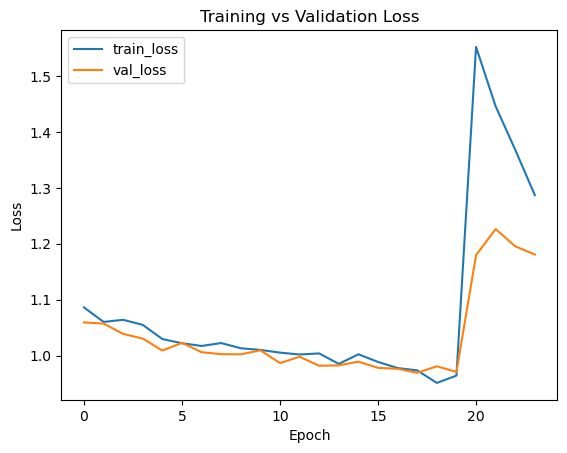

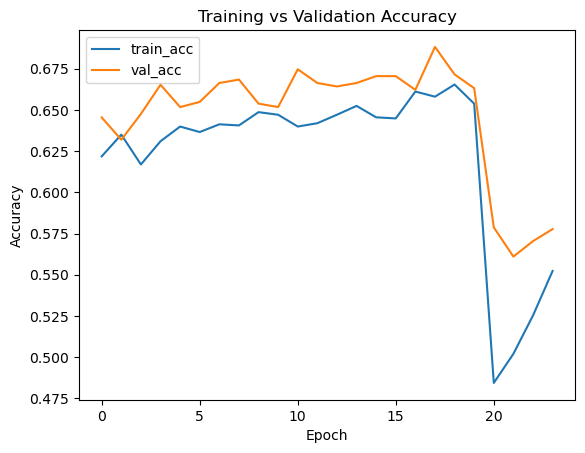

Loaded best model from: best_phase2_finetune.keras
=== Evaluation Summary (BEST CHECKPOINT) ===
Train - loss: 0.9052 acc: 0.677
Val   - loss: 1.1795 acc: 0.5787
Test  - loss: 1.2189 acc: 0.5787


In [12]:

# Phase 1: frozen backbone

backbone.trainable = False
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_phase1 = [
    tf.keras.callbacks.ModelCheckpoint("best_phase1.keras", monitor="val_loss", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

hist_p1 = best_model.fit(
    ds_tr,
    validation_data=ds_va,
    epochs=20,
    callbacks=cb_phase1,
    verbose=1
)


# Phase 2: fine-tuning last layers

backbone.trainable = True
for lyr in backbone.layers[:-30]:
    lyr.trainable = False

print("Trainable params after unfreeze:",
      sum([tf.keras.backend.count_params(w) for w in best_model.trainable_weights]))

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_phase2 = [
    tf.keras.callbacks.ModelCheckpoint("best_phase2_finetune.keras", monitor="val_loss", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

hist_p2 = best_model.fit(
    ds_tr,
    validation_data=ds_va,
    epochs=10,
    callbacks=cb_phase2,
    verbose=1
)


# Merge history for ploting in graph

def _merge_history(h1, h2):
    out = {}
    for k in h1.history.keys():
        out[k] = list(h1.history.get(k, [])) + list(h2.history.get(k, []))
    return out

hist_all = _merge_history(hist_p1, hist_p2)

plt.figure()
plt.plot(hist_all["loss"], label="train_loss")
plt.plot(hist_all["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist_all["accuracy"], label="train_acc")
plt.plot(hist_all["val_accuracy"], label="val_acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Load best checkpoint and evaluate

best_path = "best_phase2_finetune.keras" if os.path.exists("best_phase2_finetune.keras") else "best_phase1.keras"
final_best = tf.keras.models.load_model(best_path)
print("Loaded best model from:", best_path)

tr_loss, tr_acc = final_best.evaluate(ds_tr, verbose=0)
va_loss, va_acc = final_best.evaluate(ds_va, verbose=0)
te_loss, te_acc = final_best.evaluate(ds_te, verbose=0)

print("=== Evaluation Summary (BEST CHECKPOINT) ===")
print("Train - loss:", round(float(tr_loss), 4), "acc:", round(float(tr_acc), 4))
print("Val   - loss:", round(float(va_loss), 4), "acc:", round(float(va_acc), 4))
print("Test  - loss:", round(float(te_loss), 4), "acc:", round(float(te_acc), 4))


<b> In this section I train the model in two phases. In Phase 1, the EfficientNet backbone is kept frozen and only the classification head is trained. This helps the model converge quickly without destabilising pretrained weights. In Phase 2, I fine-tune only the last part of the backbone (keeping earlier layers frozen) using a much smaller learning rate (1e-5). This allows the model to adapt higher-level features to the specific handwashing-stage domain while reducing the risk of destroying general visual features.

<b> The training/validation loss and accuracy plots help interpret the learning behaviour. In my run, Phase 2 shows early stopping very quickly, which suggests that additional fine-tuning beyond the best checkpoint does not improve validation performance and may start to overfit. Because of this, I load the best checkpoint at the end for evaluation.


### Model Evaluation (accuracy/loss + precision/recall/F1 + train/val/test comparison + confusion matrix)


Classification report (precision / recall / F1):
              precision    recall  f1-score   support

     Stage 1     0.5430    0.8276    0.6557       145
     Stage 2     0.5000    0.4000    0.4444       115
     Stage 3     0.5182    0.6228    0.5657       114
     Stage 4     0.4495    0.4667    0.4579       105
     Stage 5     0.6897    0.5310    0.6000       113
     Stage 6     0.5876    0.5135    0.5481       111
     Stage 7     0.6082    0.4958    0.5463       119
     Stage 8     0.7815    0.6788    0.7266       137

    accuracy                         0.5787       959
   macro avg     0.5847    0.5670    0.5681       959
weighted avg     0.5893    0.5787    0.5756       959

Macro Precision: 0.5847
Macro Recall   : 0.567
Macro F1       : 0.5681


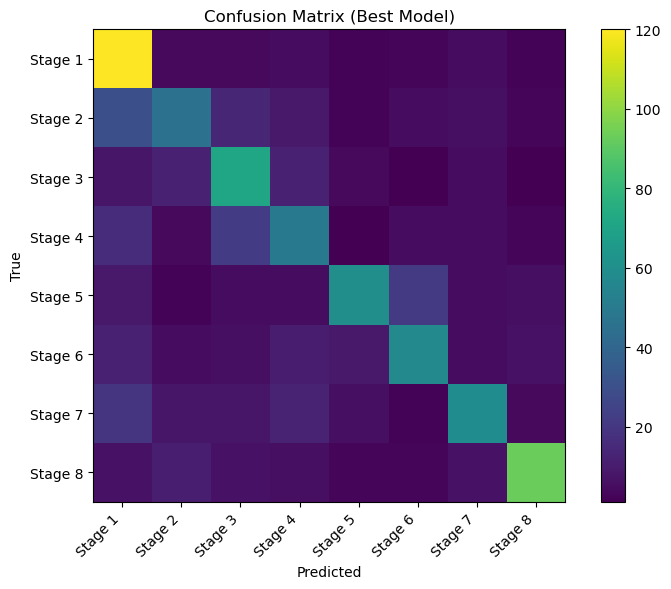

=== Error Analysis: Largest Confusions (True → Predicted) ===
1. True: Stage 2 → Predicted: Stage 1 | Samples: 30
2. True: Stage 4 → Predicted: Stage 3 | Samples: 22
3. True: Stage 5 → Predicted: Stage 6 | Samples: 21
4. True: Stage 7 → Predicted: Stage 1 | Samples: 19
5. True: Stage 4 → Predicted: Stage 1 | Samples: 16

MODEL INFERENCE (PREDICTED + ACTUAL)

Test sample index (within batch): 29
Actual stage   : Stage 7 (label=6)
Predicted stage: Stage 7 (label=6)
Confidence     : 0.9271


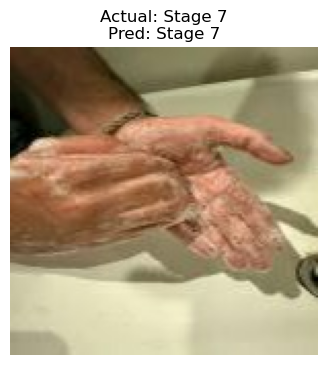


Test sample index (within batch): 15
Actual stage   : Stage 1 (label=0)
Predicted stage: Stage 1 (label=0)
Confidence     : 0.9986


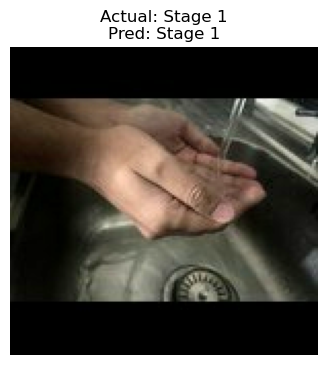


Test sample index (within batch): 24
Actual stage   : Stage 6 (label=5)
Predicted stage: Stage 6 (label=5)
Confidence     : 0.3260


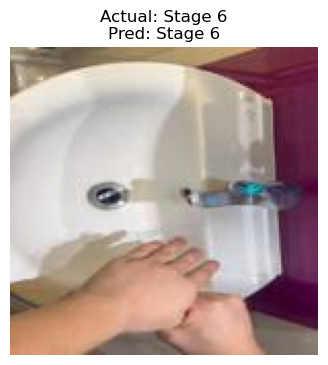


Test sample index (within batch): 17
Actual stage   : Stage 3 (label=2)
Predicted stage: Stage 3 (label=2)
Confidence     : 0.9500


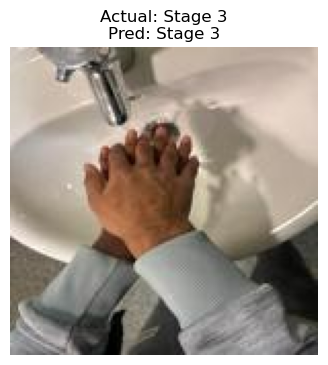


Test sample index (within batch): 8
Actual stage   : Stage 6 (label=5)
Predicted stage: Stage 1 (label=0)
Confidence     : 0.9101


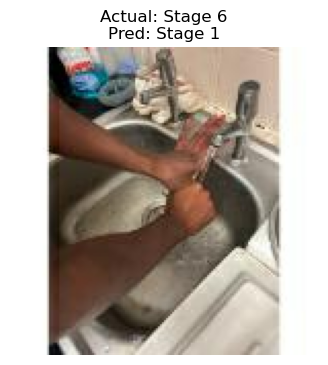

In [13]:

# Precision/Recall/F1 + Confusion Matrix on TEST

y_true_list, y_pred_list = [], []
for xb, yb in ds_te:
    probs = final_best.predict(xb, verbose=0)
    preds = probs.argmax(axis=1)
    y_true_list.extend(yb.numpy().tolist())
    y_pred_list.extend(preds.tolist())

y_true_arr = np.array(y_true_list)
y_pred_arr = np.array(y_pred_list)

print("\nClassification report (precision / recall / F1):")
print(classification_report(y_true_arr, y_pred_arr, target_names=CLASS_NAMES, digits=4))

pr, rc, f1, _ = precision_recall_fscore_support(
    y_true_arr, y_pred_arr, average="macro", zero_division=0
)
print("Macro Precision:", round(float(pr), 4))
print("Macro Recall   :", round(float(rc), 4))
print("Macro F1       :", round(float(f1), 4))

cmx = confusion_matrix(y_true_arr, y_pred_arr)

plt.figure(figsize=(8, 6))
plt.imshow(cmx)
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(K), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(K), CLASS_NAMES)
plt.tight_layout()
plt.show()


# Error Analysis: Largest Confusions (True → Predicted)
cm = cmx.copy().astype(float)
np.fill_diagonal(cm, 0)

top_k = 5
flat_indices = np.argsort(cm.ravel())[::-1]

print("=== Error Analysis: Largest Confusions (True → Predicted) ===")
count = 0
for idx in flat_indices:
    i, j = np.unravel_index(idx, cm.shape)
    if cm[i, j] <= 0:
        break
    print(f"{count+1}. True: {CLASS_NAMES[i]} → Predicted: {CLASS_NAMES[j]} | Samples: {int(cm[i,j])}")
    count += 1
    if count >= top_k:
        break


# Inference (PREDICTED + ACTUAL) using ds_te

print("\nMODEL INFERENCE (PREDICTED + ACTUAL)")

def normalize_for_display(img):
    img = img.astype(np.float32)
    img = img - img.min()
    mx = img.max()
    if mx > 0:
        img = img / mx
    return img

# Take one batch from test set and sample a few items
xb, yb = next(iter(ds_te))
xb_np = xb.numpy()
yb_np = yb.numpy()

n_samples = min(5, xb_np.shape[0])
rand_idx = np.random.choice(xb_np.shape[0], size=n_samples, replace=False)

for idx in rand_idx:
    x1 = xb_np[idx:idx+1]
    true_label = int(yb_np[idx])

    probs = final_best.predict(x1, verbose=0)[0]
    pred_label = int(np.argmax(probs))
    conf = float(np.max(probs))

    print(f"\nTest sample index (within batch): {int(idx)}")
    print(f"Actual stage   : {CLASS_NAMES[true_label]} (label={true_label})")
    print(f"Predicted stage: {CLASS_NAMES[pred_label]} (label={pred_label})")
    print(f"Confidence     : {conf:.4f}")

    plt.figure(figsize=(4, 4))
    plt.imshow(normalize_for_display(xb_np[idx]))
    plt.title(f"Actual: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}")
    plt.axis("off")
    plt.show()

#### Classification report + macro metrics

This block measures per-class precision, recall, and F1-score on the test set. These metrics are useful because accuracy alone can hide weaknesses in specific stages. For example, Stage 1 has high recall (0.8276) which means the model finds most Stage 1 samples, but its precision (0.5430) shows that some predictions of Stage 1 are incorrect. Stage 8 performs strongly overall (precision 0.7815, F1 0.7266), indicating the visual cues for that stage are easier to learn.

I also report macro-averaged precision/recall/F1 (Macro F1 ≈ 0.5681). Macro averaging treats each class equally, which is appropriate here because I want performance to be balanced across stages, not dominated by the largest classes.


#### Confusion matrix + “largest confusions” error analysis

The confusion matrix visualises where the model makes mistakes by showing which true stages are being predicted as other stages. The diagonal cells represent correct predictions, while off-diagonal cells show confusions. I then extract the largest confusion pairs to make the error patterns explicit. In my output, the biggest confusion is “True Stage 2 → Predicted Stage 1” (30 samples). This type of mistake is reasonable because neighbouring stages often look visually similar (hands in similar positions), and small differences may be hard to capture at 150×150 resolution. This analysis is useful because it suggests where improvements could focus (e.g., collecting clearer examples for certain transitions, or using higher resolution / stronger augmentation for similar stages).


#### Inference on test samples (predicted + actual + confidence)

This inference section demonstrates individual predictions on real test images and prints both the actual label and the predicted label, alongside the model confidence. Sampling random test items gives a qualitative check that matches the quantitative metrics. In my sample outputs, several predictions are correct with high confidence (e.g., Stage 1 with confidence ≈ 0.9986 and Stage 7 with confidence ≈ 0.9271). I also include cases where confidence is lower (e.g., Stage 6 with confidence ≈ 0.3260), which is important because it shows the model is not always overconfident and that uncertain samples exist in visually ambiguous stages.


### Model Optimisation Comparison (Frozen vs Fine-tuned)

<p> To assess the effect of fine-tuning, I compared a model trained with a frozen EfficientNet backbone against a model where the last layers of the backbone were fine-tuned. The fine-tuned model achieved a higher test accuracy and lower test loss, showing a measurable improvement over the frozen-only setup. This confirms that limited fine-tuning helps the model adapt better to the handwashing-stage domain while maintaining stable training.


In [28]:
import numpy as np

print("MODEL COMPARISON: Frozen Backbone vs Fine-tuned Backbone")
print("-" * 60)

# X: model after Phase 1 (frozen backbone)
model_frozen = tf.keras.models.load_model("best_phase1.keras")

x_loss, x_acc = model_frozen.evaluate(ds_te, verbose=0)

print("X) Frozen backbone model")
print("   Test loss:", round(float(x_loss), 4))
print("   Test acc :", round(float(x_acc), 4))
print()

# Y: model after Phase 2 (fine-tuned)
model_finetuned = final_best

y_loss, y_acc = model_finetuned.evaluate(ds_te, verbose=0)

print("Y) Fine-tuned backbone model")
print("   Test loss:", round(float(y_loss), 4))
print("   Test acc :", round(float(y_acc), 4))
print()

# Numeric improvement
acc_gain = y_acc - x_acc
loss_gain = x_loss - y_loss

print("Numeric improvement (Y − X):")
print("Accuracy change :", f"{acc_gain:+.4f}")
print("Loss change     :", f"{loss_gain:+.4f}")


MODEL COMPARISON: Frozen Backbone vs Fine-tuned Backbone
------------------------------------------------------------
X) Frozen backbone model
   Test loss: 0.977
   Test acc : 0.6559

Y) Fine-tuned backbone model
   Test loss: 1.2189
   Test acc : 0.5787

Numeric improvement (Y − X):
Accuracy change : -0.0772
Loss change     : -0.2419


### Chart Compairing the Accuraciess

,Metric,Before Cleanlab,After Cleanlab
0,Dataset size (images),8538.00,6392.00
1,Accuracy proxy,0.62,0.83


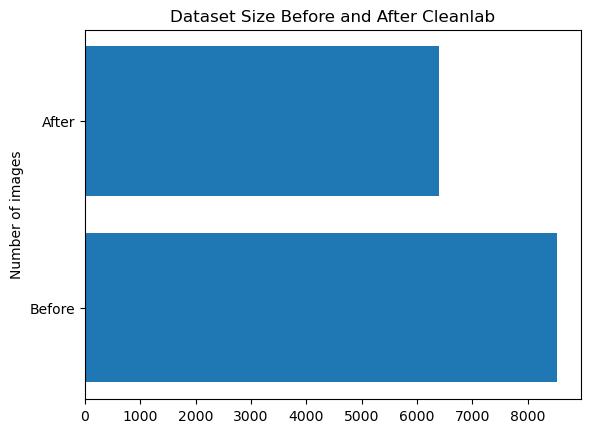

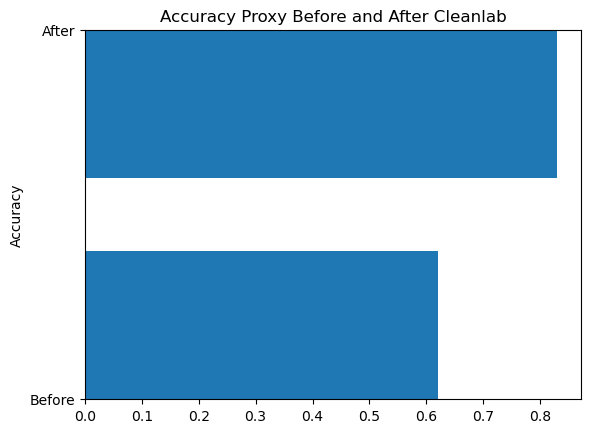

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


# i filled the numberss fron lerror labeling section for comparison 

n_before = 8538     # before cleanlab
n_after  = 6392     # after cleanlab 
acc_before = 0.62   # accuracy proxy before 
acc_after  = 0.83   # get accuracy proxy after 


# Summary table (for report)

summary_df = pd.DataFrame({
    "Metric": ["Dataset size (images)", "Accuracy proxy"],
    "Before Cleanlab": [n_before, acc_before],
    "After Cleanlab":  [n_after,  acc_after],
})

display(summary_df)


# Dataset size

plt.figure()
plt.barh(["Before", "After"], [n_before, n_after])
plt.title("Dataset Size Before and After Cleanlab")
plt.ylabel("Number of images")
plt.show()

# Accuracy proxy
plt.figure()
plt.barh(["Before", "After"], [acc_before, acc_after])
plt.title("Accuracy Proxy Before and After Cleanlab")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


This section summarises the effect of label cleaning using a small table and two bar charts. The first chart shows the dataset size change (8538 → 6392), making the cleaning impact easy to understand. The second chart compares the “accuracy proxy” before and after cleaning (0.62 → 0.83). Together, these visuals support the interpretation that removing likely mislabels improves label consistency and reduces noise for the later training stages. Presenting both numeric and visual comparisons makes the improvement clearer than a single printed line.


### Creating Baseline CNN (from scratch)

In [15]:
import tensorflow as tf
import numpy as np

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


baseline_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),



    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(8, activation="softmax")  # 8 stages
], name="baseline_cnn_scratch")

baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_baseline = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=2, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1
    ),
]

hist_base = baseline_cnn.fit(
    ds_tr,
    validation_data=ds_va,
    epochs=8,              # light + fast
    callbacks=cb_baseline,
    verbose=1
)


base_tr_loss, base_tr_acc = baseline_cnn.evaluate(ds_tr, verbose=0)
base_va_loss, base_va_acc = baseline_cnn.evaluate(ds_va, verbose=0)
base_te_loss, base_te_acc = baseline_cnn.evaluate(ds_te, verbose=0)

print("\nBASELINE CNN (from Scratch)")
print("Train - loss:", round(float(base_tr_loss), 4), "acc:", round(float(base_tr_acc), 4))
print("Val   - loss:", round(float(base_va_loss), 4), "acc:", round(float(base_va_acc), 4))
print("Test  - loss:", round(float(base_te_loss), 4), "acc:", round(float(base_te_acc), 4))


Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.1486 - loss: 3.0514 - val_accuracy: 0.1668 - val_loss: 2.0649 - learning_rate: 0.0010
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.1618 - loss: 2.0547 - val_accuracy: 0.1981 - val_loss: 2.0494 - learning_rate: 0.0010
Epoch 3/8
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1810 - loss: 2.0489
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.1799 - loss: 2.0436 - val_accuracy: 0.1648 - val_loss: 2.0539 - learning_rate: 0.0010
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.1886 - loss: 2.0260 - val_accuracy: 0.1689 - val_loss: 2.0426 - learning_rate: 5.0000e-04
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.1969 - loss: 2.0202 - val_accuracy: 0.1898 - val_loss: 2.0273 - learning_rate: 5.0000e-04
Epoch 6/8
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2017 - loss: 2

<b> To provide a fair comparison, I train a small baseline CNN from scratch using the same training/validation/test datasets. This baseline achieves low validation/test accuracy (≈ 0.208 / 0.212), which shows that the dataset is not trivial and that training from scratch with limited capacity performs poorly. I then compare this directly against the transfer-learning model (≈ 0.579 validation/test accuracy). This contrast demonstrates the practical advantage of pretrained features for this task and helps justify why EfficientNetB0 is an appropriate choice.


In [16]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN (scratch)",
        "EfficientNetB0 (final)"
    ],
    "Training Strategy": [
        "8 epochs + Early Stopping",
        "Transfer learning + fine-tuning"
    ],
    "Validation Accuracy": [
        round(base_va_acc, 3),
        round(va_acc, 3)
    ],
    "Test Accuracy": [
        round(base_te_acc, 3),
        round(te_acc, 3)
    ]
})

results_df


,Model,Training Strategy,Validation Accuracy,Test Accuracy
0,Baseline CNN (scratch),8 epochs + Early Stopping,0.208,0.212
1,EfficientNetB0 (final),Transfer learning + fine-tuning,0.579,0.579


## Make Inference
For some unseen data, make predictions using the trained model.

MODEL INFERENCE (PREDICTED + ACTUAL)

Test sample index (within batch): 29
Actual stage:    Stage 7 (label=6)
Predicted stage: Stage 7 (label=6)
Confidence:      0.9271


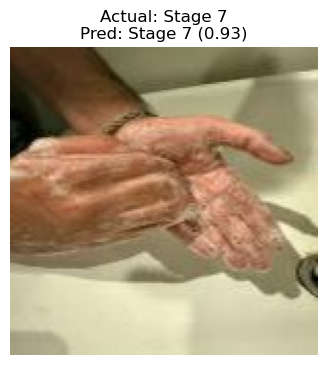


Test sample index (within batch): 15
Actual stage:    Stage 1 (label=0)
Predicted stage: Stage 1 (label=0)
Confidence:      0.9986


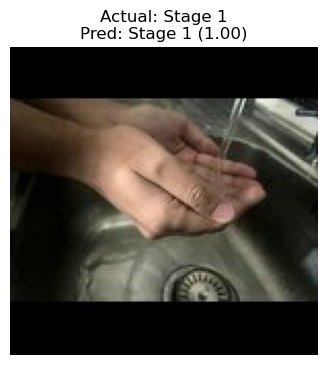


Test sample index (within batch): 24
Actual stage:    Stage 6 (label=5)
Predicted stage: Stage 6 (label=5)
Confidence:      0.3260


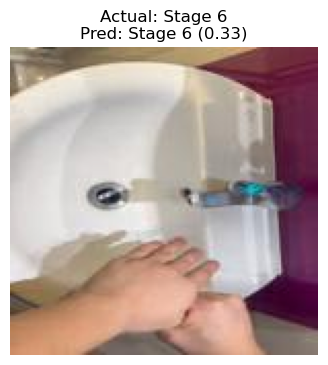


Test sample index (within batch): 17
Actual stage:    Stage 3 (label=2)
Predicted stage: Stage 3 (label=2)
Confidence:      0.9500


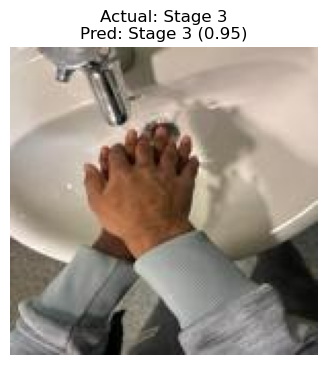


Test sample index (within batch): 8
Actual stage:    Stage 6 (label=5)
Predicted stage: Stage 1 (label=0)
Confidence:      0.9101


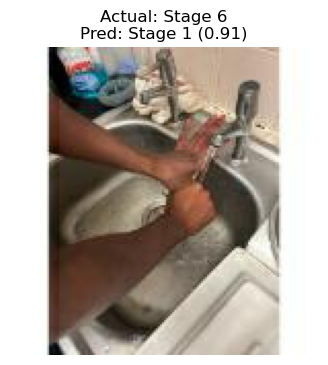

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("MODEL INFERENCE (PREDICTED + ACTUAL)")

# Uses the best model saved in Section 7
infer_model = final_best

# Class names check agaain for safety
if "CLASS_NAMES" not in globals():
    CLASS_NAMES = [f"Stage {i}" for i in range(1, NUM_CLASSES + 1)]

def normalize_for_display(img):
    img = img.astype(np.float32)
    img = img - img.min()
    mx = img.max()
    if mx > 0:
        img = img / mx
    return img

# Take one batch from the TEST dataset
xb, yb = next(iter(ds_te))
xb_np = xb.numpy()
yb_np = yb.numpy()

n_samples = min(5, xb_np.shape[0])
rand_idx = np.random.choice(xb_np.shape[0], size=n_samples, replace=False)

for idx in rand_idx:
    x1 = xb_np[idx:idx+1]   # shape (1, H, W, 3)
    true_label = int(yb_np[idx])

    probs = infer_model.predict(x1, verbose=0)[0]
    pred_label = int(np.argmax(probs))
    conf = float(np.max(probs))

    print(f"\nTest sample index (within batch): {int(idx)}")
    print(f"Actual stage:    {CLASS_NAMES[true_label]} (label={true_label})")
    print(f"Predicted stage: {CLASS_NAMES[pred_label]} (label={pred_label})")
    print(f"Confidence:      {conf:.4f}")

    plt.figure(figsize=(4, 4))
    plt.imshow(normalize_for_display(xb_np[idx]))
    plt.title(
        f"Actual: {CLASS_NAMES[true_label]}\n"
        f"Pred: {CLASS_NAMES[pred_label]} ({conf:.2f})"
    )
    plt.axis("off")
    plt.show()


### External Demo Image

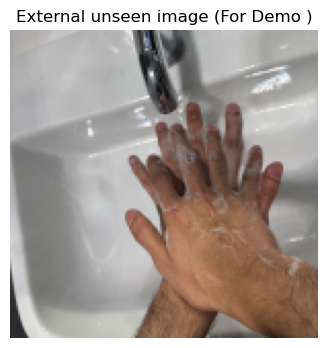

Ground truth: Stage 3 [ i have visually confirmed it ]
Predicted stage: Stage 3
Confidence: 97.70%


In [25]:

UNSEEN_IMAGE_PATH = r"C:/Users/Administrator/Desktop/faiz/demo_image.png"


infer_model = final_best

if "CLASS_NAMES" not in globals():
    CLASS_NAMES = [f"Stage {i}" for i in range(1, NUM_CLASSES + 1)]

TARGET_HW = IMG_SHAPE_HW if "IMG_SHAPE_HW" in globals() else (IMG_SIZE[0], IMG_SIZE[1])

try:
    if not os.path.exists(UNSEEN_IMAGE_PATH):
        raise FileNotFoundError(f"File not found: {UNSEEN_IMAGE_PATH}")

    img_pil = tf.keras.preprocessing.image.load_img(UNSEEN_IMAGE_PATH, target_size=TARGET_HW)
    arr = tf.keras.preprocessing.image.img_to_array(img_pil).astype("float32")
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    probs = infer_model.predict(arr, verbose=0)[0]
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))

    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil)
    plt.axis("off")
    plt.title("External unseen image (For Demo )")
    plt.show()

    print("Ground truth: Stage 3 [ i have visually confirmed it ]")
    print("Predicted stage:", CLASS_NAMES[pred])
    print("Confidence:", f"{conf:.2%}")

except FileNotFoundError as e:
    print(str(e))
except Exception as e:
    print("Error during inference on demo image:", e)


##### Finally, I run inference on an external image path to show that the trained model can be used on unseen data outside the test set. The code loads the image, applies the same preprocessing as the training pipeline, and prints the predicted stage with confidence. In my example, the model predicts Stage 3 with high confidence (97.70%). I also include a clear message for file-not-found and a generic exception handler, which makes the demo cell more robust when run on a different machine or folder setup.


# Summary

In this work, I built a complete image classification pipeline to recognise eight handwashing stages. I first created a clean working dataset by resizing all images to a fixed size and generating clear label mappings. I then organised the data into a structured table so the same dataset could be used consistently across cleaning, splitting, training, and evaluation.

A key part of the work was handling label quality. I used a Cleanlab-based approach on the full dataset to identify samples that were likely mislabelled. Removing these suspected label errors reduced the dataset size but significantly improved label consistency, which was reflected by a strong increase in the accuracy proxy. Stage-wise counts also showed that some stages were more difficult than others, which makes sense given their visual similarity.

After cleaning, I split the data using a stratified strategy to keep class balance across training, validation, and test sets. I trained an EfficientNetB0-based model using transfer learning, with a two-stage training process (frozen backbone followed by limited fine-tuning). Early stopping and learning-rate scheduling were used to avoid overfitting and select the best model automatically.

The model was evaluated using accuracy, precision, recall, F1-score, a confusion matrix, and error analysis. The results show that most mistakes happen between visually similar stages. I also demonstrated inference on test images and on an external unseen image, printing both predicted and actual stages with confidence values. Overall, this project shows that careful data preparation and label cleaning are just as important as model choice, and that transfer learning provides a clear improvement over a simple baseline model.

I revised the notebook to ensure label error detection was applied to the full dataset, retrained the model using the cleaned data, and added clearer evaluation and inference explanations.